In [1]:
from Maze.Generator import PerlinMazeGenerator, DFSMazeGenerator
from Maze.Maze import Maze
import numpy as np

In [2]:

"""perlin_gen = PerlinMazeGenerator(size=16)

perlin_grid = perlin_gen.initialize_genome()

print("Perlin Grid Shape:", perlin_grid.shape)
print(perlin_grid)
"""

'perlin_gen = PerlinMazeGenerator(size=16)\n\nperlin_grid = perlin_gen.initialize_genome()\n\nprint("Perlin Grid Shape:", perlin_grid.shape)\nprint(perlin_grid)\n'

In [3]:
"""dfs_gen = DFSMazeGenerator(size=16)

dfs_grid = dfs_gen.initialize_genome()

print("DFS Grid Shape:", dfs_grid.shape)
print(dfs_grid)"""

'dfs_gen = DFSMazeGenerator(size=16)\n\ndfs_grid = dfs_gen.initialize_genome()\n\nprint("DFS Grid Shape:", dfs_grid.shape)\nprint(dfs_grid)'

In [4]:
"""# Junction Test:
gen = PerlinMazeGenerator(size=16)
grid = gen.initialize_genome()
maze = Maze(grid)
print(maze.to_ascii())
print(maze._openness_score())

gen2 = DFSMazeGenerator(size=16)
grid2 = gen2.initialize_genome()
maze2 = Maze(grid2)
print(maze2.to_ascii())
print(maze2._openness_score())"""

'# Junction Test:\ngen = PerlinMazeGenerator(size=16)\ngrid = gen.initialize_genome()\nmaze = Maze(grid)\nprint(maze.to_ascii())\nprint(maze._openness_score())\n\ngen2 = DFSMazeGenerator(size=16)\ngrid2 = gen2.initialize_genome()\nmaze2 = Maze(grid2)\nprint(maze2.to_ascii())\nprint(maze2._openness_score())'

In [5]:
gen = PerlinMazeGenerator(size=16)
grid = gen.initialize_genome()
maze = Maze(grid)
score = maze.evaluate_structure()

print("Score:", score)
print("Start:", maze.start, "Goal:", maze.goal)
print(maze.to_ascii())

Score: (155.0476923076923, 49.0)
Start: (2, 2) Goal: (14, 5)
████████████████
█   ████       █
█ S ██████     █
█   ██████     █
█  ███████ □  □█
█ ██████    ████
█ ██████    ████
█  █████    ████
█   ████     ███
█    ████      █
█     ███      █
█              █
█              █
██            ██
██   G        ██
████████████████


In [6]:
gen = DFSMazeGenerator(size=16)
grid = gen.initialize_genome()
maze = Maze(grid)
score = maze.evaluate_structure()

print("Score:", score)
print("Start:", maze.start, "Goal:", maze.goal)
print(maze.to_ascii())

Score: (202.86879027061855, 96.0)
Start: (1, 3) Goal: (5, 7)
████████████████
█  S    █     ██
█ ███ ███ █ █ ██
█   █ █   █ █ ██
███ █ █ ███ █ ██
█   █ █G  █ █ ██
█████ █ ███ █ ██
█   █ █ █ □ █ ██
█ █ █ █ █ ███ ██
█ █□█   █ █   ██
█ ███ ███ █ ████
█ █   █   █   ██
█ █████ █████ ██
█       █     ██
████████████████
████████████████


In [7]:
from MazeSolver.Solver import AStarSolver
from Archive import MapElitesArchive, Individual
from Controller import ExperimentController

In [8]:
"""gen = PerlinMazeGenerator(size=16)
grid = gen.initialize_genome()
maze = Maze(grid)

print("Start:", maze.start, "Goal:", maze.goal)

base_fitness, base_steps = maze.evaluate_structure()
print("Baseline steps:", base_steps, "Baseline fitness:", base_fitness)

theta0 = np.array([-1.0, -0.5, 0.2, 0.0])
solver = AStarSolver(theta=theta0)

success, steps = solver.solve(maze)
print("Solver success:", success, "Solver steps:", steps)
print("Ratio solver / baseline:", steps / (base_steps + 1e-6))"""

'gen = PerlinMazeGenerator(size=16)\ngrid = gen.initialize_genome()\nmaze = Maze(grid)\n\nprint("Start:", maze.start, "Goal:", maze.goal)\n\nbase_fitness, base_steps = maze.evaluate_structure()\nprint("Baseline steps:", base_steps, "Baseline fitness:", base_fitness)\n\ntheta0 = np.array([-1.0, -0.5, 0.2, 0.0])\nsolver = AStarSolver(theta=theta0)\n\nsuccess, steps = solver.solve(maze)\nprint("Solver success:", success, "Solver steps:", steps)\nprint("Ratio solver / baseline:", steps / (base_steps + 1e-6))'

In [9]:
"""gen = PerlinMazeGenerator(size=16)
archive = MapElitesArchive(bins_f1=10, bins_f2=10)
ctrl = ExperimentController(generator=gen, archive=archive)

ctrl.initialize_archive(n=50)

envs = ctrl.sample_envs_for_solver(k=10)
print("Sampled envs:", len(envs))

total = 0
solver = AStarSolver(theta=theta0)

for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)
    base_fit, base_steps = maze.evaluate_structure()
    success, steps = solver.solve(maze)

    if not success:
        steps_used = 1000
    else:
        steps_used = steps

    print(f"Env {i}: baseline {base_steps}, solver {steps_used}, success={success}")
    total += steps_used

avg_steps = total / max(len(envs), 1)
print("Average solver steps on sampled envs:", avg_steps)"""

'gen = PerlinMazeGenerator(size=16)\narchive = MapElitesArchive(bins_f1=10, bins_f2=10)\nctrl = ExperimentController(generator=gen, archive=archive)\n\nctrl.initialize_archive(n=50)\n\nenvs = ctrl.sample_envs_for_solver(k=10)\nprint("Sampled envs:", len(envs))\n\ntotal = 0\nsolver = AStarSolver(theta=theta0)\n\nfor i, indiv in enumerate(envs):\n    maze = Maze(indiv.genome)\n    base_fit, base_steps = maze.evaluate_structure()\n    success, steps = solver.solve(maze)\n\n    if not success:\n        steps_used = 1000\n    else:\n        steps_used = steps\n\n    print(f"Env {i}: baseline {base_steps}, solver {steps_used}, success={success}")\n    total += steps_used\n\navg_steps = total / max(len(envs), 1)\nprint("Average solver steps on sampled envs:", avg_steps)'

In [10]:
pn_gen = PerlinMazeGenerator(size=16)
dfs_gen = DFSMazeGenerator(size=16)

archive = MapElitesArchive(bins_f1=20, bins_f2=20)
ctrl = ExperimentController(generator=pn_gen, archive=archive)

ctrl.initialize_archive_mixed(n=100, perlin_gen=pn_gen, dfs_gen=dfs_gen)

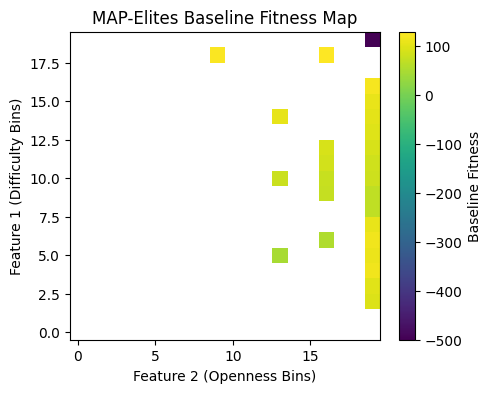

In [11]:
import matplotlib.pyplot as plt
arch = ctrl.archive

rows = arch.bins_f1
cols = arch.bins_f2

baseline_mat = np.full((rows, cols), np.nan)
solver_mat   = np.full((rows, cols), np.nan)

for i in range(rows):
    for j in range(cols):
        indiv = arch.grid[i][j]
        if indiv is None:
            continue
        baseline_mat[i, j] = indiv.baseline_fitness
        if indiv.solver_fitness is not None:
            solver_mat[i, j] = indiv.solver_fitness

plt.figure(figsize=(5, 4))
plt.imshow(baseline_mat, origin="lower", aspect="auto")
plt.colorbar(label="Baseline Fitness")
plt.xlabel("Feature 2 (Openness Bins)")
plt.ylabel("Feature 1 (Difficulty Bins)")
plt.title("MAP-Elites Baseline Fitness Map")
plt.show()

In [12]:
"""envs = ctrl.sample_envs_for_solver(k=10)
print("Selected envs:", len(envs))

theta0 = np.array([-1.0, -0.5, 0.2, 0.0])
solver = AStarSolver(theta=theta0)

penalty_steps = 1000
total_steps = 0.0

for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)

    base_fit, base_steps = maze.evaluate_structure()
    success, steps = solver.solve(maze)

    if not success:
        steps_used = penalty_steps
    else:
        steps_used = steps

    print(
        f"Env {i}: baseline {base_steps:.0f}, "
        f"solver {steps_used}, success={success}"
    )
    total_steps += steps_used

avg_steps = total_steps / max(len(envs), 1)
print("Average solver steps on sampled envs:", avg_steps)"""

'envs = ctrl.sample_envs_for_solver(k=10)\nprint("Selected envs:", len(envs))\n\ntheta0 = np.array([-1.0, -0.5, 0.2, 0.0])\nsolver = AStarSolver(theta=theta0)\n\npenalty_steps = 1000\ntotal_steps = 0.0\n\nfor i, indiv in enumerate(envs):\n    maze = Maze(indiv.genome)\n\n    base_fit, base_steps = maze.evaluate_structure()\n    success, steps = solver.solve(maze)\n\n    if not success:\n        steps_used = penalty_steps\n    else:\n        steps_used = steps\n\n    print(\n        f"Env {i}: baseline {base_steps:.0f}, "\n        f"solver {steps_used}, success={success}"\n    )\n    total_steps += steps_used\n\navg_steps = total_steps / max(len(envs), 1)\nprint("Average solver steps on sampled envs:", avg_steps)'

In [13]:
from MazeSolver.Solver import GreedySolver

In [14]:
# FINALLY WORKS MY GREEDY BABY
"""envs = ctrl.sample_envs_for_solver(k=10)

theta0 = np.array([-1.0, -0.5, 0.2, 0.0])
solver = GreedySolver(theta=theta0)

# penalty_steps = 1000
total = 0.0

for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)
    base_fit, base_steps = maze.evaluate_structure()
    success, steps = solver.solve(maze)
    steps_used = steps

    print(
        f"Env {i}: baseline {base_steps:.0f}, "
        f"solver {steps_used}, success={success}"
    )
    total += steps_used

print("Average greedy steps:", total / max(len(envs), 1))"""

'envs = ctrl.sample_envs_for_solver(k=10)\n\ntheta0 = np.array([-1.0, -0.5, 0.2, 0.0])\nsolver = GreedySolver(theta=theta0)\n\n# penalty_steps = 1000\ntotal = 0.0\n\nfor i, indiv in enumerate(envs):\n    maze = Maze(indiv.genome)\n    base_fit, base_steps = maze.evaluate_structure()\n    success, steps = solver.solve(maze)\n    steps_used = steps\n\n    print(\n        f"Env {i}: baseline {base_steps:.0f}, "\n        f"solver {steps_used}, success={success}"\n    )\n    total += steps_used\n\nprint("Average greedy steps:", total / max(len(envs), 1))'

In [15]:
# Feasibility test
"""ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)

for gen in range(20):
    ctrl.evolve_solvers_one_generation(
        k_envs=16,
        mu=10,
        lambd=20,
        sigma=0.3,
    )

    pop = ctrl.solver_population
    best = max(pop, key=lambda s: s.fitness)
    avg_fit = sum(s.fitness for s in pop) / len(pop)
    print(f"Gen {gen}: best fitness {best.fitness:.2f}, avg {avg_fit:.2f}")"""

'ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)\n\nfor gen in range(20):\n    ctrl.evolve_solvers_one_generation(\n        k_envs=16,\n        mu=10,\n        lambd=20,\n        sigma=0.3,\n    )\n\n    pop = ctrl.solver_population\n    best = max(pop, key=lambda s: s.fitness)\n    avg_fit = sum(s.fitness for s in pop) / len(pop)\n    print(f"Gen {gen}: best fitness {best.fitness:.2f}, avg {avg_fit:.2f}")'

In [16]:
# Feasibility test 2
"""ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)
for gen in range(40):
    ctrl.evolve_solvers_one_generation(
        k_envs=5,
        mu=6,
        lambd=12,
        sigma=0.3,
    )

    pop = ctrl.solver_population
    evaluated = [s for s in pop if s.fitness != 0.0]
    best_fit = max(evaluated, key=lambda s: s.fitness).fitness
    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)
    print(f"Gen {gen}: best {best_fit:.2f}, avg {avg_fit:.2f}")

envs = ctrl.sample_envs_for_solver(k=5)
best = max(
    [s for s in ctrl.solver_population if s.fitness != 0.0],
    key=lambda s: s.fitness,
)

solver = GreedySolver(theta=best.theta)

for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)
    base_fit, base_steps = maze.evaluate_structure()
    success, steps = solver.solve(maze)
    print(f"Env {i}: baseline {base_steps:.0f}, solver {steps}, success={success}")"""

'ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)\nfor gen in range(40):\n    ctrl.evolve_solvers_one_generation(\n        k_envs=5,\n        mu=6,\n        lambd=12,\n        sigma=0.3,\n    )\n\n    pop = ctrl.solver_population\n    evaluated = [s for s in pop if s.fitness != 0.0]\n    best_fit = max(evaluated, key=lambda s: s.fitness).fitness\n    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)\n    print(f"Gen {gen}: best {best_fit:.2f}, avg {avg_fit:.2f}")\n\nenvs = ctrl.sample_envs_for_solver(k=5)\nbest = max(\n    [s for s in ctrl.solver_population if s.fitness != 0.0],\n    key=lambda s: s.fitness,\n)\n\nsolver = GreedySolver(theta=best.theta)\n\nfor i, indiv in enumerate(envs):\n    maze = Maze(indiv.genome)\n    base_fit, base_steps = maze.evaluate_structure()\n    success, steps = solver.solve(maze)\n    print(f"Env {i}: baseline {base_steps:.0f}, solver {steps}, success={success}")'

In [17]:
# Feasibility test 3
"""ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)
for gen in range(50):
    ctrl.evolve_solvers_one_generation(
        k_envs=5,
        mu=6,
        lambd=12,
        sigma=0.3,
    )

    pop = ctrl.solver_population
    evaluated = [s for s in pop if s.fitness != 0.0]
    best_fit = max(evaluated, key=lambda s: s.fitness).fitness
    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)
    print(f"Gen {gen}: best {best_fit:.2f}, avg {avg_fit:.2f}")

envs = ctrl.sample_easy_envs_for_solver(k=5)
best = max(
    [s for s in ctrl.solver_population if s.fitness != 0.0],
    key=lambda s: s.fitness,
)

solver = GreedySolver(theta=best.theta)

for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)
    base_fit, base_steps = maze.evaluate_structure()
    success, steps = solver.solve(maze)
    print(f"Env {i}: baseline {base_steps:.0f}, solver {steps}, success={success}")"""

'ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)\nfor gen in range(50):\n    ctrl.evolve_solvers_one_generation(\n        k_envs=5,\n        mu=6,\n        lambd=12,\n        sigma=0.3,\n    )\n\n    pop = ctrl.solver_population\n    evaluated = [s for s in pop if s.fitness != 0.0]\n    best_fit = max(evaluated, key=lambda s: s.fitness).fitness\n    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)\n    print(f"Gen {gen}: best {best_fit:.2f}, avg {avg_fit:.2f}")\n\nenvs = ctrl.sample_easy_envs_for_solver(k=5)\nbest = max(\n    [s for s in ctrl.solver_population if s.fitness != 0.0],\n    key=lambda s: s.fitness,\n)\n\nsolver = GreedySolver(theta=best.theta)\n\nfor i, indiv in enumerate(envs):\n    maze = Maze(indiv.genome)\n    base_fit, base_steps = maze.evaluate_structure()\n    success, steps = solver.solve(maze)\n    print(f"Env {i}: baseline {base_steps:.0f}, solver {steps}, success={success}")'

In [18]:
def evaluate_on_envs_with_success(theta: np.ndarray, envs: list[Individual]) -> tuple[float, float]:
    solver = GreedySolver(theta=theta)
    total_steps = 0.0
    success_count = 0

    for ind in envs:
        maze = Maze(ind.genome)
        _, base_steps = maze.evaluate_structure()
        success, steps = solver.solve(maze)
        total_steps += float(steps)
        if success:
            success_count += 1

    avg_steps = total_steps / max(len(envs), 1)
    success_rate = success_count / max(len(envs), 1)
    return avg_steps, success_rate

def evaluate_with_baseline_and_relative(
    theta: np.ndarray,
    envs: list[Individual],
) -> tuple[float, float, float]:
    """
    For A Given Theta And A Set Of Environments:

        - Build GreedySolver(theta)
        - For Each Env:
            - Compute baseline_steps from Maze.evaluate_structure()
            - Run solver.solve() to get solver_steps, success
            - Compute relative score:
                  score_env = min(1.0, baseline_steps / solver_steps)

        Returns:
            avg_solver_steps, success_rate, avg_relative_score
    """
    solver = GreedySolver(theta=theta)

    total_steps = 0.0
    total_score = 0.0
    success_count = 0
    count = 0

    for ind in envs:
        maze = Maze(ind.genome)
        _, baseline_steps = maze.evaluate_structure()

        if baseline_steps <= 0:
            continue 

        success, solver_steps = solver.solve(maze)
        solver_steps = float(solver_steps)

        if solver_steps <= 0:
            continue

        ratio = baseline_steps / solver_steps
        score_env = min(1.0, ratio)

        total_steps += solver_steps
        total_score += score_env
        count += 1

        if success:
            success_count += 1

    if count == 0:
        return 0.0, 0.0, 0.0

    avg_steps = total_steps / count
    success_rate = success_count / count
    avg_score = total_score / count
    return avg_steps, success_rate, avg_score

In [19]:
# Phase 1 test 1
"""ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)

train_envs = ctrl.sample_easy_envs_for_solver(k=10)
test_envs  = ctrl.sample_easy_envs_for_solver(k=5)

for gen in range(50):
    ctrl.evolve_solvers_one_generation(
        k_envs=8,   
        mu=6,
        lambd=12,
        sigma=0.3,
    )

    pop = ctrl.solver_population
    evaluated = [s for s in pop if s.fitness != 0.0]
    best_fit = max(evaluated, key=lambda s: s.fitness).fitness
    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)
    print(f"Gen {gen}: best {best_fit:.2f}, avg {avg_fit:.2f}")
    # SEE HOW IT GOES PER 5 GENS
    if gen % 5 == 0:
        best = max(evaluated, key=lambda s: s.fitness)
        train_avg, train_sr = evaluate_on_envs_with_success(best.theta, train_envs)
        test_avg,  test_sr  = evaluate_on_envs_with_success(best.theta, test_envs)
        print(
            f"[Eval @ Gen {gen}] "
            f"Train avg {train_avg:.1f}, SR {train_sr:.2f}; "
            f"Test avg {test_avg:.1f}, SR {test_sr:.2f}"
        )   

envs = ctrl.sample_easy_envs_for_solver(k=5)
best = max(
    [s for s in ctrl.solver_population if s.fitness != 0.0],
    key=lambda s: s.fitness,
)

solver = GreedySolver(theta=best.theta)

for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)
    base_fit, base_steps = maze.evaluate_structure()
    success, steps = solver.solve(maze)
    print(f"Env {i}: baseline {base_steps:.0f}, solver {steps}, success={success}")"""

'ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)\n\ntrain_envs = ctrl.sample_easy_envs_for_solver(k=10)\ntest_envs  = ctrl.sample_easy_envs_for_solver(k=5)\n\nfor gen in range(50):\n    ctrl.evolve_solvers_one_generation(\n        k_envs=8,   \n        mu=6,\n        lambd=12,\n        sigma=0.3,\n    )\n\n    pop = ctrl.solver_population\n    evaluated = [s for s in pop if s.fitness != 0.0]\n    best_fit = max(evaluated, key=lambda s: s.fitness).fitness\n    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)\n    print(f"Gen {gen}: best {best_fit:.2f}, avg {avg_fit:.2f}")\n    # SEE HOW IT GOES PER 5 GENS\n    if gen % 5 == 0:\n        best = max(evaluated, key=lambda s: s.fitness)\n        train_avg, train_sr = evaluate_on_envs_with_success(best.theta, train_envs)\n        test_avg,  test_sr  = evaluate_on_envs_with_success(best.theta, test_envs)\n        print(\n            f"[Eval @ Gen {gen}] "\n            f"Train avg {train_avg:.1f}, SR {train_sr:.2f}; "\n 

In [20]:
# Phase 1 test 2
"""ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)
train_envs = ctrl.sample_easy_envs_for_solver(k=10)
test_envs  = ctrl.sample_easy_envs_for_solver(k=5)

for gen in range(50):
    ctrl.evolve_solvers_one_generation(
        k_envs=8,   
        mu=6,
        lambd=12,
        sigma=0.3,
    )

    pop = ctrl.solver_population
    evaluated = [s for s in pop if s.fitness != 0.0]

    best_fit = max(evaluated, key=lambda s: s.fitness).fitness
    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)

    print(f"Gen {gen}: best {best_fit:.3f}, avg {avg_fit:.3f}")

    if gen % 5 == 0:
        best = max(evaluated, key=lambda s: s.fitness)

        train_avg, train_sr, train_rel = evaluate_with_baseline_and_relative(
            best.theta, train_envs
        )
        test_avg, test_sr, test_rel = evaluate_with_baseline_and_relative(
            best.theta, test_envs
        )

        print(
            f"[Eval @ Gen {gen}] "
            f"Train: steps {train_avg:.1f}, SR {train_sr:.2f}, rel {train_rel:.2f}; "
            f"Test: steps {test_avg:.1f}, SR {test_sr:.2f}, rel {test_rel:.2f}"
        )

envs = ctrl.sample_easy_envs_for_solver(k=5)
best = max(
    [s for s in ctrl.solver_population if s.fitness != 0.0],
    key=lambda s: s.fitness,
)

solver = GreedySolver(theta=best.theta)
for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)
    _, base_steps = maze.evaluate_structure()
    success, steps = solver.solve(maze)

    if steps > 0:
        rel = min(1.0, base_steps / float(steps))
    else:
        rel = 0.0

    print(
        f"Env {i}: baseline {base_steps:.0f}, "
        f"solver {steps}, success={success}, rel={rel:.2f}"
    )
"""


'ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)\ntrain_envs = ctrl.sample_easy_envs_for_solver(k=10)\ntest_envs  = ctrl.sample_easy_envs_for_solver(k=5)\n\nfor gen in range(50):\n    ctrl.evolve_solvers_one_generation(\n        k_envs=8,   \n        mu=6,\n        lambd=12,\n        sigma=0.3,\n    )\n\n    pop = ctrl.solver_population\n    evaluated = [s for s in pop if s.fitness != 0.0]\n\n    best_fit = max(evaluated, key=lambda s: s.fitness).fitness\n    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)\n\n    print(f"Gen {gen}: best {best_fit:.3f}, avg {avg_fit:.3f}")\n\n    if gen % 5 == 0:\n        best = max(evaluated, key=lambda s: s.fitness)\n\n        train_avg, train_sr, train_rel = evaluate_with_baseline_and_relative(\n            best.theta, train_envs\n        )\n        test_avg, test_sr, test_rel = evaluate_with_baseline_and_relative(\n            best.theta, test_envs\n        )\n\n        print(\n            f"[Eval @ Gen {gen}] "\n           

In [21]:
# CP coef analysis

"""ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)
train_envs = ctrl.sample_easy_envs_for_solver(k=10)
test_envs  = ctrl.sample_easy_envs_for_solver(k=5)

alphas = [0.0, 0.2, 0.5, 0.8, 1.0]
results = []

for gen in range(21):
    ctrl.evolve_solvers_one_generation(
        k_envs=10,   
        mu=6,
        lambd=12,
        sigma=0.3,
    )

    pop = ctrl.solver_population
    evaluated = [s for s in pop if s.fitness != 0.0]

    best_fit = max(evaluated, key=lambda s: s.fitness).fitness
    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)

    print(f"Gen {gen}: best {best_fit:.3f}, avg {avg_fit:.3f}")

    if gen % 5 == 0:
        best = max(evaluated, key=lambda s: s.fitness)

        train_avg, train_sr, train_rel = evaluate_with_baseline_and_relative(
            best.theta, train_envs
        )
        test_avg, test_sr, test_rel = evaluate_with_baseline_and_relative(
            best.theta, test_envs
        )

        print(
            f"[Eval @ Gen {gen}] "
            f"Train: steps {train_avg:.1f}, SR {train_sr:.2f}, rel {train_rel:.2f}; "
            f"Test: steps {test_avg:.1f}, SR {test_sr:.2f}, rel {test_rel:.2f}"
        )

envs = ctrl.sample_easy_envs_for_solver(k=5)
best = max(
    [s for s in ctrl.solver_population if s.fitness != 0.0],
    key=lambda s: s.fitness,
)

solver = GreedySolver(theta=best.theta)

for alpha in alphas:
    rel_list = []
    for ind in envs:
        maze = Maze(ind.genome)
        _, baseline_steps = maze.evaluate_structure()
        if baseline_steps <= 0:
            continue

        success, raw_steps, cp_ratio = solver.solve_with_stats(maze)
        if raw_steps <= 0:
            continue

        eff_steps = raw_steps - alpha * cp_ratio * raw_steps
        eff_steps = max(1, int(eff_steps))

        rel = min(1.0, baseline_steps / eff_steps)
        rel_list.append(rel)

    avg_rel = np.mean(rel_list) if rel_list else 0.0
    results.append((alpha, avg_rel))

for alpha, avg_rel in results:
    print(f"alpha={alpha:.2f}, avg_rel={avg_rel:.3f}")"""


'ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)\ntrain_envs = ctrl.sample_easy_envs_for_solver(k=10)\ntest_envs  = ctrl.sample_easy_envs_for_solver(k=5)\n\nalphas = [0.0, 0.2, 0.5, 0.8, 1.0]\nresults = []\n\nfor gen in range(21):\n    ctrl.evolve_solvers_one_generation(\n        k_envs=10,   \n        mu=6,\n        lambd=12,\n        sigma=0.3,\n    )\n\n    pop = ctrl.solver_population\n    evaluated = [s for s in pop if s.fitness != 0.0]\n\n    best_fit = max(evaluated, key=lambda s: s.fitness).fitness\n    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)\n\n    print(f"Gen {gen}: best {best_fit:.3f}, avg {avg_fit:.3f}")\n\n    if gen % 5 == 0:\n        best = max(evaluated, key=lambda s: s.fitness)\n\n        train_avg, train_sr, train_rel = evaluate_with_baseline_and_relative(\n            best.theta, train_envs\n        )\n        test_avg, test_sr, test_rel = evaluate_with_baseline_and_relative(\n            best.theta, test_envs\n        )\n\n        pr

In [22]:
"""solver = GreedySolver(theta=best.theta)

envs = ctrl.sample_easy_envs_for_solver(k=50)

records = []
for ind in envs:
    maze = Maze(ind.genome)
    _, baseline_steps = maze.evaluate_structure()
    cp_count = maze.checkpoint_count()

    success, raw_steps, cp_ratio = solver.solve_with_stats(maze)

    if raw_steps <= 0:
        continue

    alpha = 0.5
    eff_steps = raw_steps - alpha * cp_ratio * raw_steps
    eff_steps = max(1, int(eff_steps))

    rel = min(1.0, baseline_steps / eff_steps)

    records.append({
        "baseline": float(baseline_steps),
        "raw": float(raw_steps),
        "eff": float(eff_steps),
        "cp_count": cp_count,
        "cp_ratio": cp_ratio,
        "success": success,
        "rel": rel,
    })"""

'solver = GreedySolver(theta=best.theta)\n\nenvs = ctrl.sample_easy_envs_for_solver(k=50)\n\nrecords = []\nfor ind in envs:\n    maze = Maze(ind.genome)\n    _, baseline_steps = maze.evaluate_structure()\n    cp_count = maze.checkpoint_count()\n\n    success, raw_steps, cp_ratio = solver.solve_with_stats(maze)\n\n    if raw_steps <= 0:\n        continue\n\n    alpha = 0.5\n    eff_steps = raw_steps - alpha * cp_ratio * raw_steps\n    eff_steps = max(1, int(eff_steps))\n\n    rel = min(1.0, baseline_steps / eff_steps)\n\n    records.append({\n        "baseline": float(baseline_steps),\n        "raw": float(raw_steps),\n        "eff": float(eff_steps),\n        "cp_count": cp_count,\n        "cp_ratio": cp_ratio,\n        "success": success,\n        "rel": rel,\n    })'

In [23]:
import pandas as pd
"""df = pd.DataFrame(records)

plt.figure()
plt.scatter(df["baseline"], df["eff"], alpha=0.6)
plt.plot([df["baseline"].min(), df["baseline"].max()],
         [df["baseline"].min(), df["baseline"].max()],
         linestyle="--")
plt.xlabel("Baseline steps (BFS all-CP)")
plt.ylabel("Greedy effective steps")
plt.title("Baseline vs Greedy (current CP weight)")
plt.show()"""

'df = pd.DataFrame(records)\n\nplt.figure()\nplt.scatter(df["baseline"], df["eff"], alpha=0.6)\nplt.plot([df["baseline"].min(), df["baseline"].max()],\n         [df["baseline"].min(), df["baseline"].max()],\n         linestyle="--")\nplt.xlabel("Baseline steps (BFS all-CP)")\nplt.ylabel("Greedy effective steps")\nplt.title("Baseline vs Greedy (current CP weight)")\nplt.show()'

In [24]:
pn_gen = PerlinMazeGenerator(size=16)
dfs_gen = DFSMazeGenerator(size=16)

archive = MapElitesArchive(bins_f1=20, bins_f2=20)
ctrl = ExperimentController(generator=pn_gen, archive=archive)

ctrl.initialize_archive_mixed(n=100, perlin_gen=pn_gen, dfs_gen=dfs_gen)

import matplotlib.pyplot as plt
arch = ctrl.archive

rows = arch.bins_f1
cols = arch.bins_f2

baseline_mat = np.full((rows, cols), np.nan)
solver_mat   = np.full((rows, cols), np.nan)

for i in range(rows):
    for j in range(cols):
        indiv = arch.grid[i][j]
        if indiv is None:
            continue
        baseline_mat[i, j] = indiv.baseline_fitness
        if indiv.solver_fitness is not None:
            solver_mat[i, j] = indiv.solver_fitness 

In [ ]:
def compare_solver_vs_baseline(theta, envs, alpha_cp=0.5):
    solver = GreedySolver(theta=theta)
    records = []

    for indiv in envs:
        maze = Maze(indiv.genome)
        base_fit, baseline_steps = maze.evaluate_structure_noCP()
        baseline_steps = float(max(1.0, baseline_steps))

        success, raw_steps, cp_ratio = solver.solve_with_stats(maze)
        raw_steps = float(max(1.0, raw_steps))
        cp_ratio = float(np.clip(cp_ratio, 0.0, 1.0))

        speed_ratio = baseline_steps / raw_steps
        cp_factor = (1 - alpha_cp) + alpha_cp * cp_ratio
        rel_score = float(np.clip(speed_ratio * cp_factor, 0.0, 1.0))

        records.append(
            (baseline_steps, raw_steps, cp_ratio, rel_score, success)
        )

    return records

In [26]:
ctrl.initialize_solvers(mu=10, theta_dim=4, init_scale=1.0)
train_envs = ctrl.sample_easy_envs_for_solver(k=10)
test_envs  = ctrl.sample_easy_envs_for_solver(k=5)

results = []

for gen in range(41):
    ctrl.evolve_solvers_one_generation(
        k_envs=10,   
        mu=6,
        lambd=12,
        sigma=0.3,
    )

    pop = ctrl.solver_population
    evaluated = [s for s in pop if s.fitness != 0.0]

    best_fit = max(evaluated, key=lambda s: s.fitness).fitness
    avg_fit = sum(s.fitness for s in evaluated) / len(evaluated)

    print(f"Gen {gen}: best {best_fit:.3f}, avg {avg_fit:.3f}")

    if gen % 5 == 0:
        best = max(evaluated, key=lambda s: s.fitness)

        train_avg, train_sr, train_rel = evaluate_with_baseline_and_relative(
            best.theta, train_envs
        )
        test_avg, test_sr, test_rel = evaluate_with_baseline_and_relative(
            best.theta, test_envs
        )

        print(
            f"[Eval @ Gen {gen}] "
            f"Train: steps {train_avg:.1f}, SR {train_sr:.2f}, rel {train_rel:.2f}; "
            f"Test: steps {test_avg:.1f}, SR {test_sr:.2f}, rel {test_rel:.2f}"
        )

envs = ctrl.sample_easy_envs_for_solver(k=5)
best = max(
    [s for s in ctrl.solver_population if s.fitness != 0.0],
    key=lambda s: s.fitness,
)

solver = GreedySolver(theta=best.theta)
for i, indiv in enumerate(envs):
    maze = Maze(indiv.genome)
    _, base_steps = maze.evaluate_structure_noCP()
    success, steps = solver.solve(maze)

    if steps > 0:
        rel = min(1.0, base_steps / float(steps))
    else:
        rel = 0.0

    print(
        f"Env {i}: baseline {base_steps:.0f}, "
        f"solver {steps}, success={success}, rel={rel:.2f}"
    )

Gen 0: best 0.429, avg 0.256
[Eval @ Gen 0] Train: steps 116.3, SR 0.60, rel 0.81; Test: steps 177.0, SR 0.60, rel 0.72
Gen 1: best 0.446, avg 0.371
Gen 2: best 0.434, avg 0.386
Gen 3: best 0.465, avg 0.402
Gen 4: best 0.475, avg 0.439
Gen 5: best 0.420, avg 0.390
[Eval @ Gen 5] Train: steps 154.6, SR 0.80, rel 0.81; Test: steps 264.2, SR 0.60, rel 0.64
Gen 6: best 0.564, avg 0.424
Gen 7: best 0.467, avg 0.416
Gen 8: best 0.513, avg 0.392
Gen 9: best 0.459, avg 0.407
Gen 10: best 0.440, avg 0.386
[Eval @ Gen 10] Train: steps 85.2, SR 0.90, rel 0.83; Test: steps 46.4, SR 0.80, rel 0.84
Gen 11: best 0.418, avg 0.385
Gen 12: best 0.464, avg 0.423
Gen 13: best 0.469, avg 0.392
Gen 14: best 0.442, avg 0.383
Gen 15: best 0.513, avg 0.425
[Eval @ Gen 15] Train: steps 235.3, SR 0.60, rel 0.69; Test: steps 288.0, SR 0.60, rel 0.61
Gen 16: best 0.495, avg 0.430
Gen 17: best 0.489, avg 0.445
Gen 18: best 0.501, avg 0.408
Gen 19: best 0.411, avg 0.388
Gen 20: best 0.536, avg 0.416
[Eval @ Gen 20] 

In [27]:
best = max(
    [s for s in ctrl.solver_population if s.fitness != 0.0],
    key=lambda s: s.fitness,
)
envs = ctrl.sample_easy_envs_for_solver(k=20)

records = compare_solver_vs_baseline(best.theta, envs, alpha_cp=0.5)

for i, (b, r, cp, rel, succ) in enumerate(records):
    print(
        f"Env {i}: base={b:.0f}, raw={r:.0f}, cp={cp:.2f}, "
        f"rel={rel:.2f}, success={succ}"
    )

Env 0: base=24, raw=56, cp=0.50, rel=0.32, success=True
Env 1: base=19, raw=111, cp=0.00, rel=0.09, success=True
Env 2: base=12, raw=12, cp=0.33, rel=0.67, success=True
Env 3: base=58, raw=1024, cp=0.00, rel=0.03, success=False
Env 4: base=29, raw=1024, cp=0.50, rel=0.02, success=False
Env 5: base=11, raw=11, cp=0.00, rel=0.50, success=True
Env 6: base=33, raw=55, cp=1.00, rel=0.60, success=True
Env 7: base=21, raw=37, cp=0.00, rel=0.28, success=True
Env 8: base=11, raw=11, cp=0.33, rel=0.67, success=True
Env 9: base=15, raw=1024, cp=0.00, rel=0.01, success=False
Env 10: base=17, raw=1024, cp=1.00, rel=0.02, success=False
Env 11: base=12, raw=12, cp=0.00, rel=0.50, success=True
Env 12: base=34, raw=1024, cp=0.50, rel=0.02, success=False
Env 13: base=24, raw=1024, cp=1.00, rel=0.02, success=False
Env 14: base=15, raw=105, cp=0.00, rel=0.07, success=True
Env 15: base=53, raw=1024, cp=0.00, rel=0.03, success=False
Env 16: base=60, raw=88, cp=0.50, rel=0.51, success=True
Env 17: base=24, r